Multi-planet systems
- Sun + Jupiter
- Sun + Jupiter + Saturn
- Sun + Jupiter + Saturn + Uranus
- Sun + Jupiter + Saturn + Uranus + Earth

In [1]:
# Importing crap
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm
import numexpr

import astropy.units as u
import astropy.constants as c

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

Defining attributes

In [2]:
# Distance to source plane
D_s = 8 * u.kpc

# Distance to lens plane
D_l = 4 * u.kpc

theta_ein, r_ein = IRSF.IRSFunctions.e_ring([D_s, D_l], 1)
print(f'Einstein ring radius: {r_ein}')
print(f'Einstein ring angle: {theta_ein}')

r_jup = 5.2 * u.au
r_saturn = 9.5 * u.au
r_earth = 1 * u.au
r_uranus = 19.2 * u.au

s_jup = (r_jup / r_ein).to(u.dimensionless_unscaled).value
s_saturn = (r_saturn / r_ein).to(u.dimensionless_unscaled).value
s_earth = (r_earth / r_ein).to(u.dimensionless_unscaled).value
s_uranus = (r_uranus / r_ein).to(u.dimensionless_unscaled).value

q_jup = (c.M_jup / c.M_sun).to(u.dimensionless_unscaled).value
q_saturn = (5.683e26 * u.kg / c.M_sun).to(u.dimensionless_unscaled).value
q_earth = (c.M_earth / c.M_sun).to(u.dimensionless_unscaled).value
q_uranus = (8.681e25 * u.kg / c.M_sun).to(u.dimensionless_unscaled).value

print(f's_jup = {s_jup:.3f}')
print(f's_saturn = {s_saturn:.3f}')
print(f's_earth = {s_earth:.3f}')
print(f's_uranus = {s_uranus:.3f}')

print(f'q_jup = {q_jup:.3e}')
print(f'q_saturn = {q_saturn:.3e}')
print(f'q_earth = {q_earth:.3e}')
print(f'q_uranus = {q_uranus:.3e}')

Einstein ring radius: 4.035803086556719 AU
Einstein ring angle: 1.0089507716391797 mas
s_jup = 1.288
s_saturn = 2.354
s_earth = 0.248
s_uranus = 4.757
q_jup = 9.546e-04
q_saturn = 2.858e-04
q_earth = 3.003e-06
q_uranus = 4.366e-05


Running Sun + Jupiter

In [3]:
sun_jupiter_lens_att = np.array([
    [0, 0, 1],
    [s_jup, 0, q_jup]
])

center_of_magnification = np.array([q_jup / ((1 + q_jup) * (s_jup + 1/s_jup)), 0])
print(f'Binary offset: {center_of_magnification}')

sun_jupiter_lens_att[:, :2] -= center_of_magnification

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(sun_jupiter_lens_att, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')
print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

(y_plus, y_minus), min_mag = IRSF.IRSFunctions._annulus_bounds_calculator(ang_width, qs, ss)
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

num_r, num_theta = IRSF.IRSFunctions._num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

Binary offset: [0.00046193 0.        ]
Pixels = 4607, Angular Width = 0.33502742168597877, Max Source Radius = 0.0727299366228233, Min Source Radius = 0.000727299366228233
Annulus bounds: y+ = 1.1316152394421348, y- = 0.8828576046682406, Min Magnification in Annulus = 4.056895881009251
Number of rays: num_r = 1712856, num_theta = 428214
Total number of rays: 7.335e+11


In [4]:
lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': sun_jupiter_lens_att.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim_sun_jupiter = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
magnifications_sun_jupiter = sim_sun_jupiter.series_calculate(cm_offset='auto', annulus_offset=center_of_magnification)

100%|██████████| 500/500 [00:04<00:00, 118.85it/s]

---------------------
Total time: 4.27 seconds


Plotting magnification map: 0.036 seconds


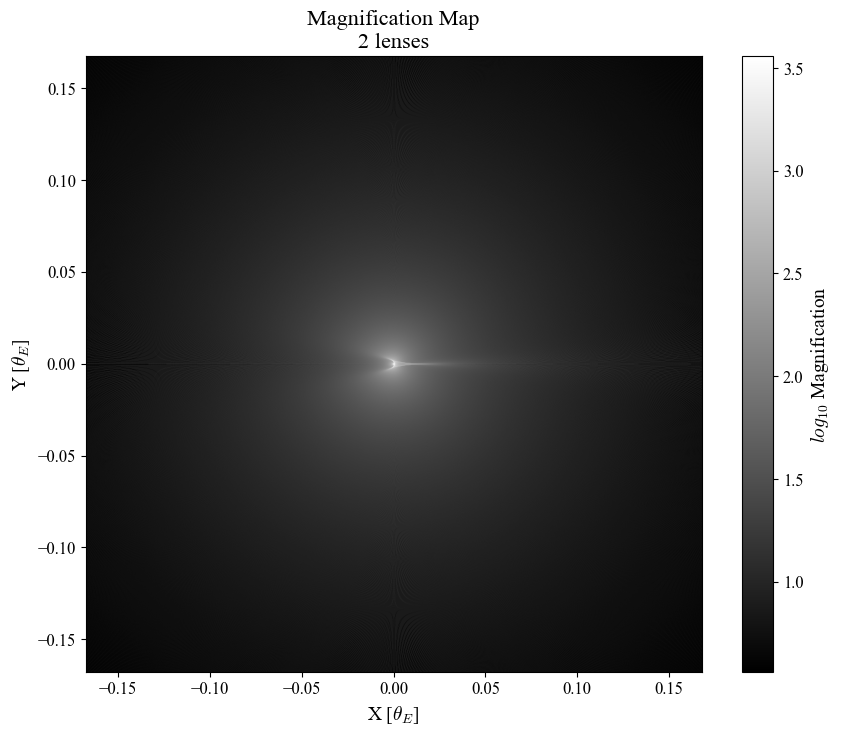

In [5]:
sim_sun_jupiter.plot()

plt.show()

Running Sun + Jupiter + Saturn

In [6]:
alpha_saturn = np.deg2rad(-45)

sun_jupiter_saturn_lens_att = np.array([
    [0, 0, 1],
    [s_jup, 0, q_jup],
    [s_saturn * np.cos(alpha_saturn), s_saturn * np.sin(alpha_saturn), q_saturn]
])

sun_jupiter_saturn_lens_att[:, :2] -= center_of_magnification

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(sun_jupiter_saturn_lens_att, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')
print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

(y_plus, y_minus), min_mag = IRSF.IRSFunctions._annulus_bounds_calculator(ang_width, qs, ss)
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

num_r, num_theta = IRSF.IRSFunctions._num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

Pixels = 4607, Angular Width = 0.33502742168597877, Max Source Radius = 0.0727299366228233, Min Source Radius = 0.000727299366228233
Annulus bounds: y+ = 1.1319354138159257, y- = 0.8828576046682406, Min Magnification in Annulus = 4.056895881009251
Number of rays: num_r = 1714096, num_theta = 428524
Total number of rays: 7.345e+11


In [7]:
lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': sun_jupiter_saturn_lens_att.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim_sun_jupiter_saturn = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
magnifications_sun_jupiter_saturn = sim_sun_jupiter_saturn.series_calculate(cm_offset='auto', annulus_offset=center_of_magnification)

100%|██████████| 500/500 [00:04<00:00, 122.85it/s]

---------------------
Total time: 4.073 seconds


Plotting magnification map: 0.015 seconds


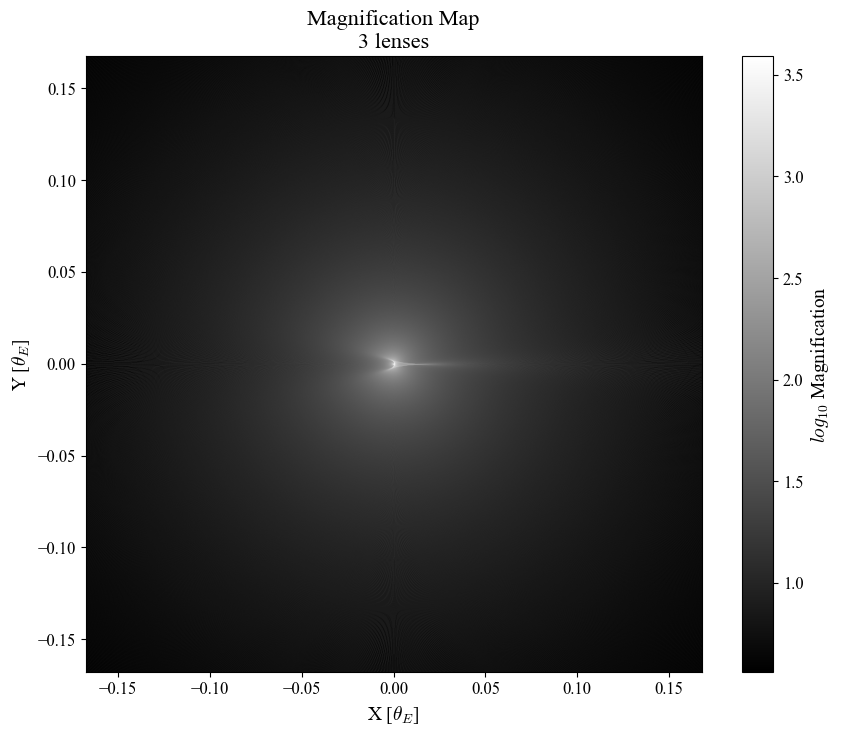

In [8]:
sim_sun_jupiter_saturn.plot()

plt.show()

Running Sun + Jupiter + Saturn + Uranus

In [9]:
alpha_uranus = -120

four_lens_att = np.array([
    [0, 0, 1],
    [s_jup, 0, q_jup],
    [s_saturn * np.cos(alpha_saturn), s_saturn * np.sin(alpha_saturn), q_saturn],
    [s_uranus * np.cos(np.deg2rad(alpha_uranus)), s_uranus * np.sin(np.deg2rad(alpha_uranus)), q_uranus]
])

four_lens_att[:, :2] -= center_of_magnification

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(four_lens_att, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')
print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

(y_plus, y_minus), min_mag = IRSF.IRSFunctions._annulus_bounds_calculator(ang_width, qs, ss)
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

num_r, num_theta = IRSF.IRSFunctions._num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

Pixels = 4607, Angular Width = 0.33502742168597877, Max Source Radius = 0.0727299366228233, Min Source Radius = 0.000727299366228233
Annulus bounds: y+ = 1.1320555131852073, y- = 0.8828576046682406, Min Magnification in Annulus = 4.056895881009251
Number of rays: num_r = 1714560, num_theta = 428640
Total number of rays: 7.349e+11


In [10]:
lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': four_lens_att.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim_four_lenses = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
magnifications_four_lenses = sim_four_lenses.series_calculate(cm_offset='auto')

100%|██████████| 500/500 [00:04<00:00, 121.13it/s]

---------------------
Total time: 4.131 seconds


Plotting magnification map: 0.035 seconds


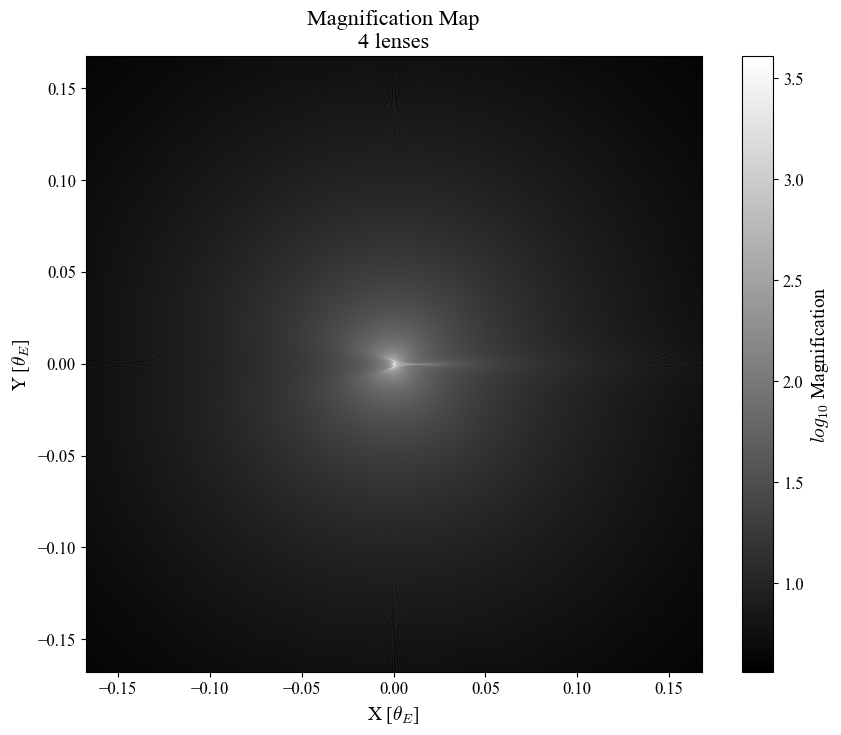

In [11]:
sim_four_lenses.plot()

plt.show()

Running Sun + Jupiter + Saturn + Uranus + Earth

In [12]:
alpha_earth = 30

five_lens_att = np.array([
    [0, 0, 1],
    [s_jup, 0, q_jup],
    [s_saturn * np.cos(alpha_saturn), s_saturn * np.sin(alpha_saturn), q_saturn],
    [s_earth * np.cos(np.deg2rad(alpha_earth)), s_earth * np.sin(np.deg2rad(alpha_earth)), q_earth],
    [s_uranus * np.cos(np.deg2rad(alpha_uranus)), s_uranus * np.sin(np.deg2rad(alpha_uranus)), q_uranus]
])

five_lens_att[:, :2] -= center_of_magnification

pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(five_lens_att, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')
print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

(y_plus, y_minus), min_mag = IRSF.IRSFunctions._annulus_bounds_calculator(ang_width, qs, ss)
print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

num_r, num_theta = IRSF.IRSFunctions._num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}')
print(f'Total number of rays: {(num_r * num_theta):.3e}')

Pixels = 4607, Angular Width = 0.33502742168597877, Max Source Radius = 0.0727299366228233, Min Source Radius = 0.000727299366228233
Annulus bounds: y+ = 1.132077174511849, y- = 0.8828576046682406, Min Magnification in Annulus = 4.056895881009251
Number of rays: num_r = 1714644, num_theta = 428661
Total number of rays: 7.350e+11


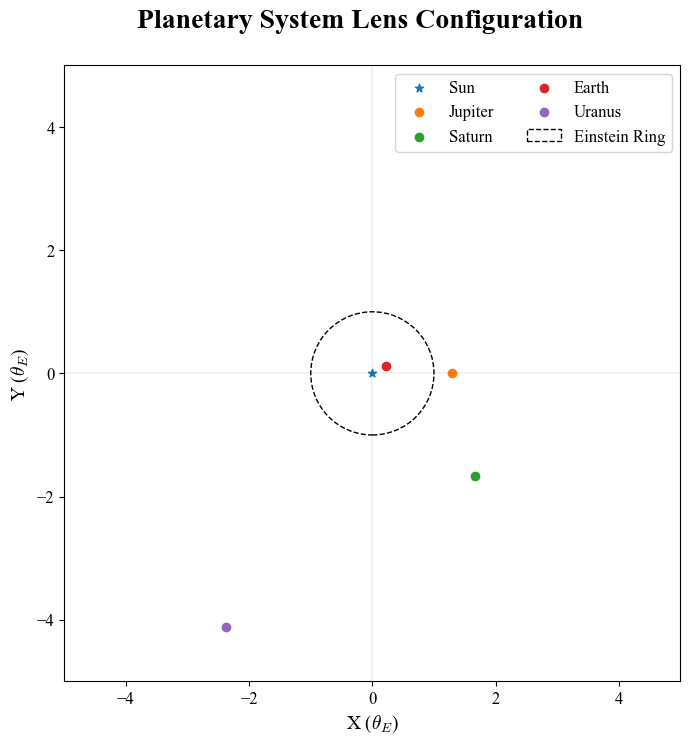

In [13]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Planetary System Lens Configuration', y=0.95)

labels = ['Sun', 'Jupiter', 'Saturn', 'Earth', 'Uranus']

for i in range(five_lens_att.shape[0]):
    ax.scatter(five_lens_att[i, 0], five_lens_att[i, 1], label=labels[i], marker='*' if i == 0 else 'o')

ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')
ax.add_patch(ring_patch)

ax.set_aspect('equal')

ax.set_xlabel(r'X ($\theta_E$)')
ax.set_ylabel(r'Y ($\theta_E$)')

view = 5
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.legend(ncol=2, loc='upper right')

# fig.savefig('Lens Configuration.png', dpi=300)

plt.show()

In [14]:
lens_parameters = {
    'pixels': 1000,
    'ang_width': ang_width,
    'thickness': y_plus - y_minus,
    'y_plus': y_plus,
    'y_minus': y_minus,
    'lens_att': five_lens_att.tolist(),
    'num_theta': 5000,
    'num_r': 20000
}

sim_five_lenses = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
magnifications_five_lenses = sim_five_lenses.series_calculate(cm_offset='auto')

100%|██████████| 500/500 [00:04<00:00, 119.84it/s]

---------------------
Total time: 4.176 seconds


Plotting magnification map: 0.014 seconds


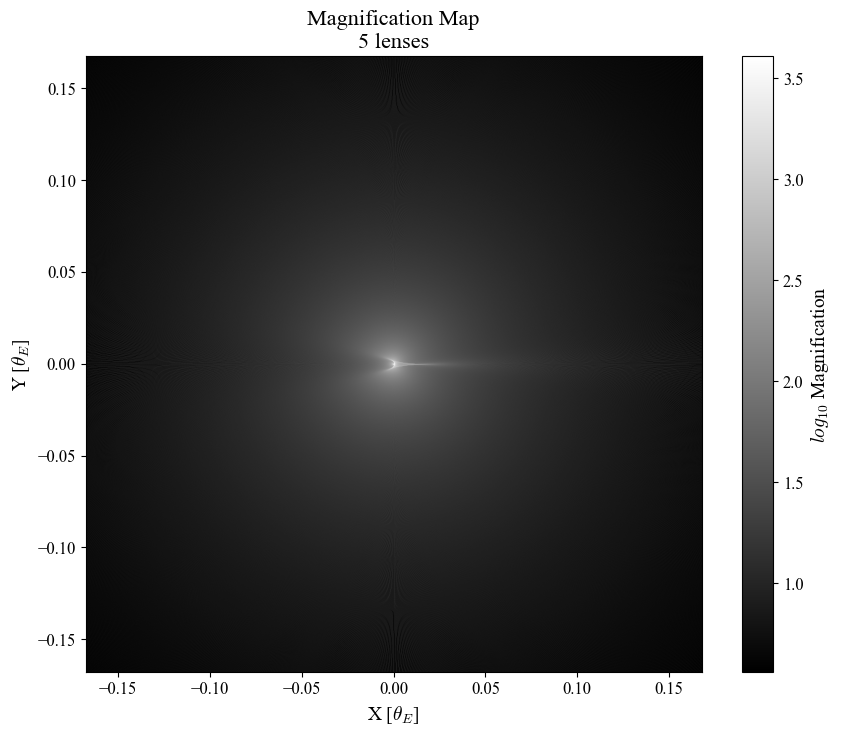

In [15]:
sim_five_lenses.plot()

plt.show()

Source radii

In [16]:
print(f'Max source radius: {max_source_radius} * theta_E')
print(f'Min source radius: {min_source_radius} * theta_E')

# Converting to mas
max_source_radius_angular = max_source_radius * theta_ein
min_source_radius_angular = min_source_radius * theta_ein
print(f'Max source radius: {max_source_radius_angular}')
print(f'Min source radius: {min_source_radius_angular}')

# Converting to solar radii
max_source_radius_solar = max_source_radius_angular.to(u.rad).value * D_l.to(u.m).value
min_source_radius_solar = min_source_radius_angular.to(u.rad).value * D_l.to(u.m).value
print(f'Max source radius: {max_source_radius_solar / c.R_sun.to(u.m).value}')
print(f'Min source radius: {min_source_radius_solar / c.R_sun.to(u.m).value}')

Max source radius: 0.0727299366228233 * theta_E
Min source radius: 0.000727299366228233 * theta_E
Max source radius: 0.0733809256768662 mas
Min source radius: 0.000733809256768662 mas
Max source radius: 63.11703453358712
Min source radius: 0.6311703453358711


## Analysis of all eight planets

In [25]:
# Distance to source plane
D_s = 8 * u.kpc

# Distance to lens plane
D_l = 4 * u.kpc

theta_ein, r_ein = IRSF.IRSFunctions.e_ring([D_s, D_l], 1)
print(f'Einstein ring radius: {r_ein}')
print(f'Einstein ring angle: {theta_ein}')

planets = ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune']

# Defining semimajor axes
r_mercury = 0.387
r_venus = 0.723
r_earth = 1
r_mars = 1.524
r_jupiter = 5.2
r_saturn = 9.5
r_uranus = 19.2
r_neptune = 30.07

planet_semimajor_axes = np.array([r_mercury, r_venus, r_earth, r_mars, r_jupiter, r_saturn, r_uranus, r_neptune]) * u.au # au

# Calculating in terms of theta_E
planet_ss = (planet_semimajor_axes / r_ein).to(u.dimensionless_unscaled).value # theta_E

# Defining masses
m_mercury = 0.330103e24
m_venus = 4.86731e24
m_earth = 5.97217e24
m_mars = 0.641691e24
m_jupiter = 1898.125e24
m_saturn = 568.317e24
m_uranus = 86.8099e24
m_neptune = 102.4092e24

planet_masses = np.array([m_mercury, m_venus, m_earth, m_mars, m_jupiter, m_saturn, m_uranus, m_neptune]) * u.kg # kg

# Calculating in terms of M_sun
planet_qs = (planet_masses / c.M_sun).to(u.dimensionless_unscaled).value # dimensionless

# Defining shears
planet_shears = []
for i in range(len(planets)):
    q = planet_qs[i]
    s = planet_ss[i]
    if s < 1:
        planet_shears.append(q * s**2)
    else:
        planet_shears.append(q * (1/s)**2)

planet_shears = np.array(planet_shears)

# Defining planet angles
seed = 2
np.random.seed(seed)
planet_alphas = np.random.uniform(0, 360, len(planets))

# Adding all attributes to a Pandas DataFrame
planet_attributes = pd.DataFrame({
    'Planet': planets,
    'Semimajor Axis [au]': planet_semimajor_axes,
    's': planet_ss,
    'Mass [kg]': planet_masses,
    'q': planet_qs,
    'Shear': planet_shears,
    'Angle [deg]': planet_alphas
})

planet_attributes

Einstein ring radius: 4.035803086556719 AU
Einstein ring angle: 1.0089507716391797 mas


,Planet,Semimajor Axis [au],s,Mass [kg],q,Shear,Angle [deg]
0,Mercury,0.387,0.095892,3.301030e+23,1.660136e-07,1.526531e-09,156.958165
1,Venus,0.723,0.179147,4.867310e+24,2.447840e-06,7.855969e-08,9.333443
2,Earth,1.000,0.247782,5.972170e+24,3.003490e-06,1.844023e-07,197.878492
3,Mars,1.524,0.377620,6.416910e+23,3.227157e-07,4.601824e-08,156.716061
4,Jupiter,5.200,1.288467,1.898125e+27,9.545944e-04,5.750057e-04,151.332409
5,Saturn,9.500,2.353931,5.683170e+26,2.858148e-04,5.158192e-05,118.920536
6,Uranus,19.200,4.757417,8.680990e+25,4.365795e-05,1.928949e-06,73.673508
7,Neptune,30.070,7.450810,1.024092e+26,5.150306e-05,9.277397e-07,222.937548


In [26]:
# Sorting planets by shear
planet_attributes = planet_attributes.sort_values(by='Shear', ascending=False)

planet_attributes

,Planet,Semimajor Axis [au],s,Mass [kg],q,Shear,Angle [deg]
4,Jupiter,5.200,1.288467,1.898125e+27,9.545944e-04,5.750057e-04,151.332409
5,Saturn,9.500,2.353931,5.683170e+26,2.858148e-04,5.158192e-05,118.920536
6,Uranus,19.200,4.757417,8.680990e+25,4.365795e-05,1.928949e-06,73.673508
7,Neptune,30.070,7.450810,1.024092e+26,5.150306e-05,9.277397e-07,222.937548
2,Earth,1.000,0.247782,5.972170e+24,3.003490e-06,1.844023e-07,197.878492
1,Venus,0.723,0.179147,4.867310e+24,2.447840e-06,7.855969e-08,9.333443
3,Mars,1.524,0.377620,6.416910e+23,3.227157e-07,4.601824e-08,156.716061
0,Mercury,0.387,0.095892,3.301030e+23,1.660136e-07,1.526531e-09,156.958165


Defining lens attributes

In [41]:
lens_att = []
lens_att.append([0, 0, 1])

for i in range(len(planets)):
    lens_att.append([planet_attributes['s'].iloc[i] * np.cos(np.deg2rad(planet_attributes['Angle [deg]'].iloc[i])), planet_attributes['s'].iloc[i] * np.sin(np.deg2rad(planet_attributes['Angle [deg]'].iloc[i])), planet_attributes['q'].iloc[i]])

lens_att = np.array(lens_att)

lens_att

array([[ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [-1.13052389e+00,  6.18112867e-01,  9.54594436e-04],
       [-1.13835168e+00,  2.06037479e+00,  2.85814815e-04],
       [ 1.33735982e+00,  4.56557657e+00,  4.36579506e-05],
       [-5.45471262e+00, -5.07549727e+00,  5.15030636e-05],
       [-2.35816687e-01, -7.60689695e-02,  3.00349042e-06],
       [ 1.76774820e-01,  2.90539472e-02,  2.44784039e-06],
       [-3.46865588e-01,  1.49268668e-01,  3.22715658e-07],
       [-8.82413898e-02,  3.75323109e-02,  1.66013559e-07]])

Showing planet configuration

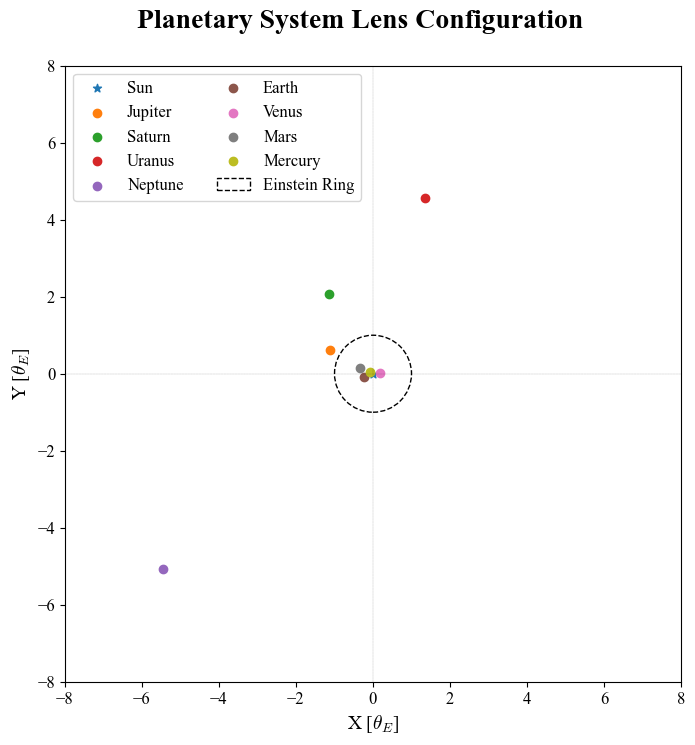

In [44]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Planetary System Lens Configuration', y=0.95)

for i in range(lens_att.shape[0]):
    ax.scatter(lens_att[i, 0], lens_att[i, 1], label=planet_attributes['Planet'].iloc[i-1] if i != 0 else 'Sun', marker='*' if i == 0 else 'o')

ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')
ax.add_patch(ring_patch)

ax.set_aspect('equal')

ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

view = 8
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.legend(ncol=2, loc='best')

# fig.savefig('Lens Configuration.png', dpi=300)

plt.show()

Creating magnification maps

Binary offset: [0.00046193 0.        ]
4    Jupiter
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
Annulus bounds: y+ = 1.1281839134688458, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1671896, num_theta = 417974, Total number of rays: 6.988e+11


100%|██████████| 500/500 [00:04<00:00, 114.04it/s]


---------------------
Total time: 4.391 seconds
Plotting magnification map: 0.027 seconds


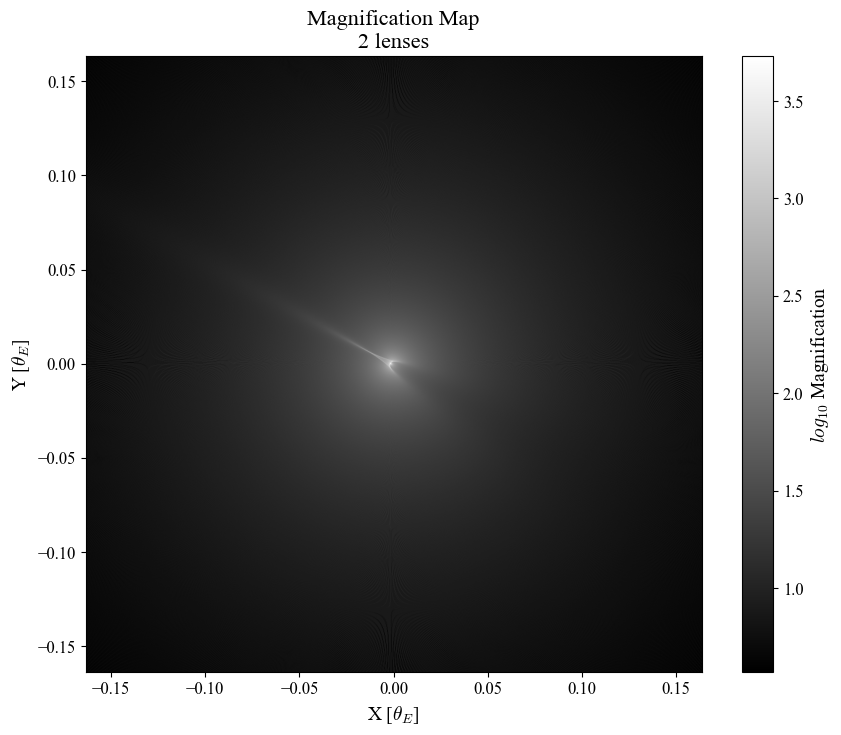

4    Jupiter
5     Saturn
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
Annulus bounds: y+ = 1.128504454996557, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673132, num_theta = 418283, Total number of rays: 6.998e+11


100%|██████████| 500/500 [00:04<00:00, 121.61it/s]


---------------------
Total time: 4.115 seconds
Plotting magnification map: 0.014 seconds


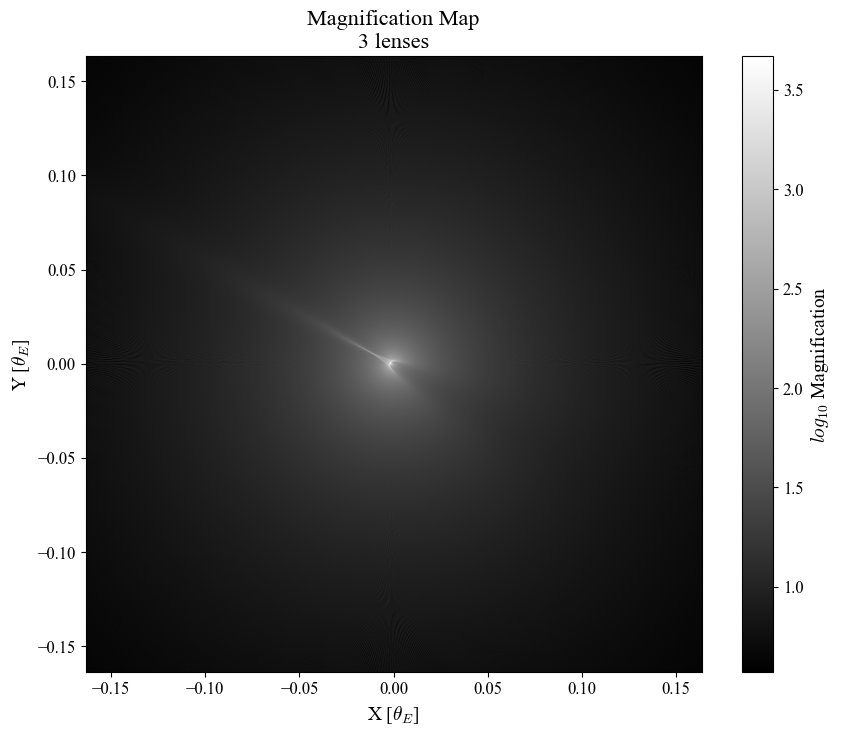

4    Jupiter
5     Saturn
6     Uranus
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
Annulus bounds: y+ = 1.1286246028063949, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673596, num_theta = 418399, Total number of rays: 7.002e+11


100%|██████████| 500/500 [00:04<00:00, 120.47it/s]


---------------------
Total time: 4.154 seconds
Plotting magnification map: 0.028 seconds


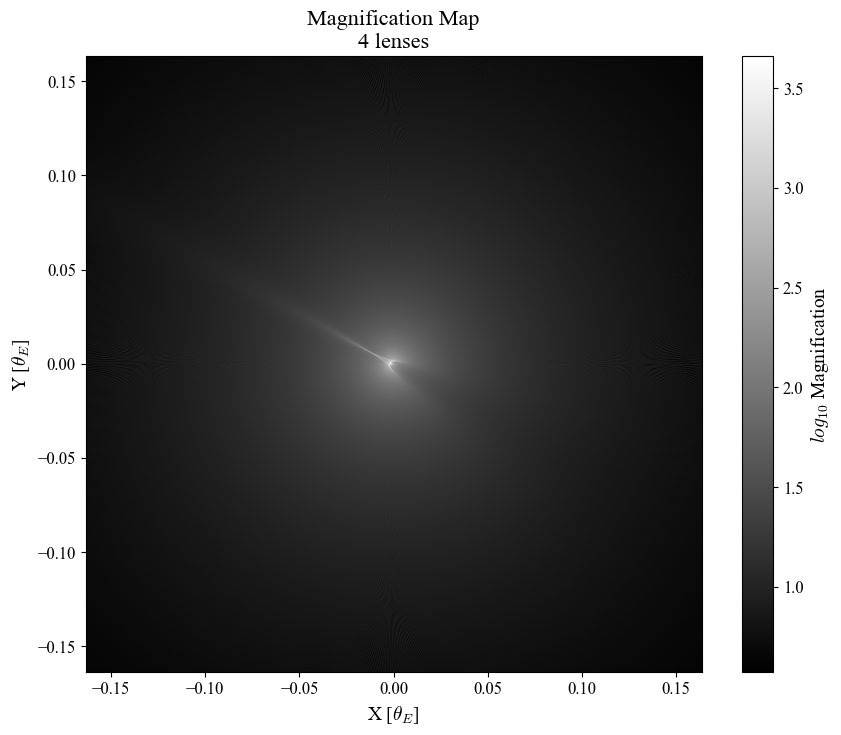

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
Annulus bounds: y+ = 1.1286246028063949, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673596, num_theta = 418399, Total number of rays: 7.002e+11


100%|██████████| 500/500 [00:04<00:00, 108.75it/s]


---------------------
Total time: 4.601 seconds
Plotting magnification map: 0.014 seconds


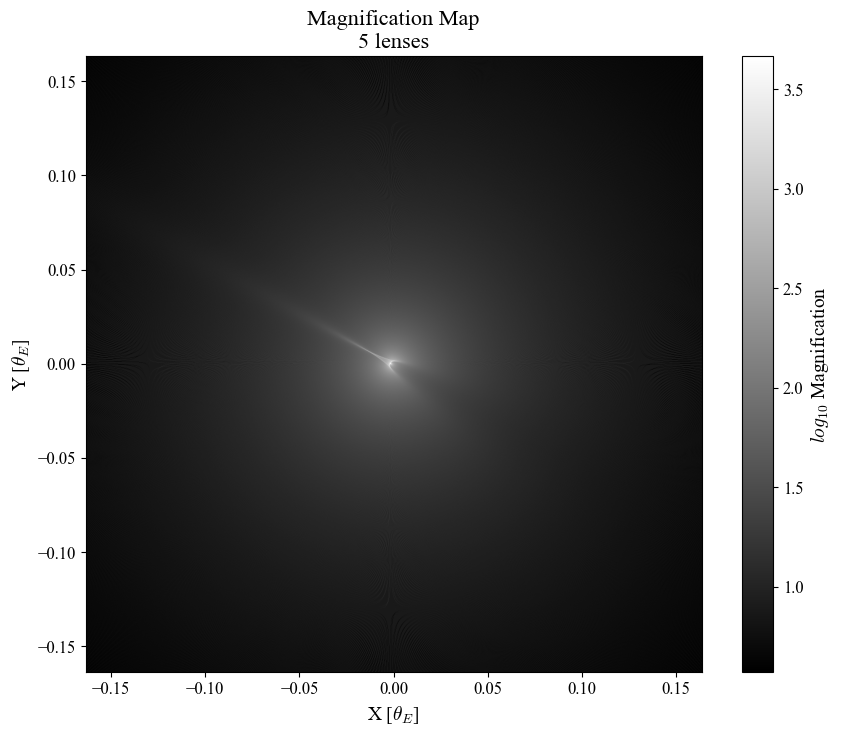

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
Annulus bounds: y+ = 1.1286462721248667, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673680, num_theta = 418420, Total number of rays: 7.003e+11


100%|██████████| 500/500 [00:04<00:00, 114.41it/s]


---------------------
Total time: 4.373 seconds
Plotting magnification map: 0.014 seconds


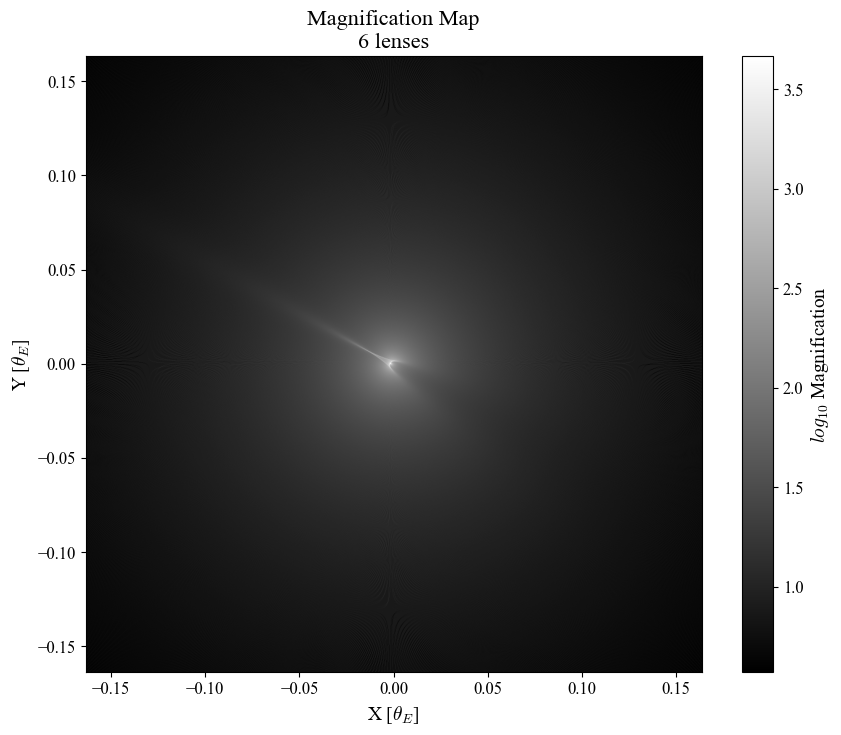

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
1      Venus
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
Annulus bounds: y+ = 1.128646272125348, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673680, num_theta = 418420, Total number of rays: 7.003e+11


100%|██████████| 500/500 [00:04<00:00, 110.01it/s]


---------------------
Total time: 4.549 seconds
Plotting magnification map: 0.013 seconds


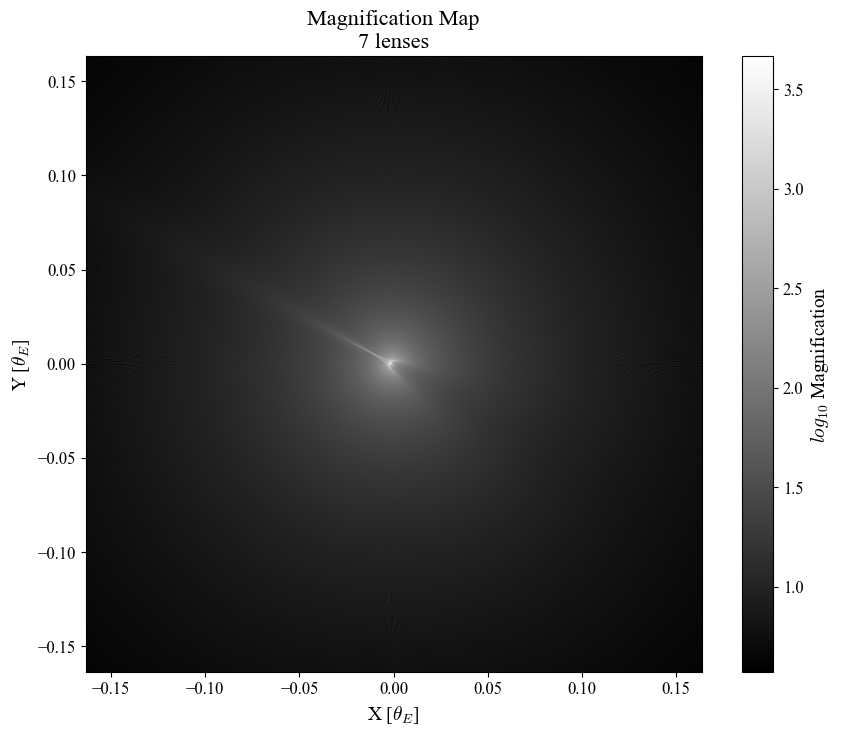

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
1      Venus
3       Mars
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
Annulus bounds: y+ = 1.128646272125567, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673680, num_theta = 418420, Total number of rays: 7.003e+11


100%|██████████| 500/500 [00:04<00:00, 113.03it/s]


---------------------
Total time: 4.427 seconds
Plotting magnification map: 0.013 seconds


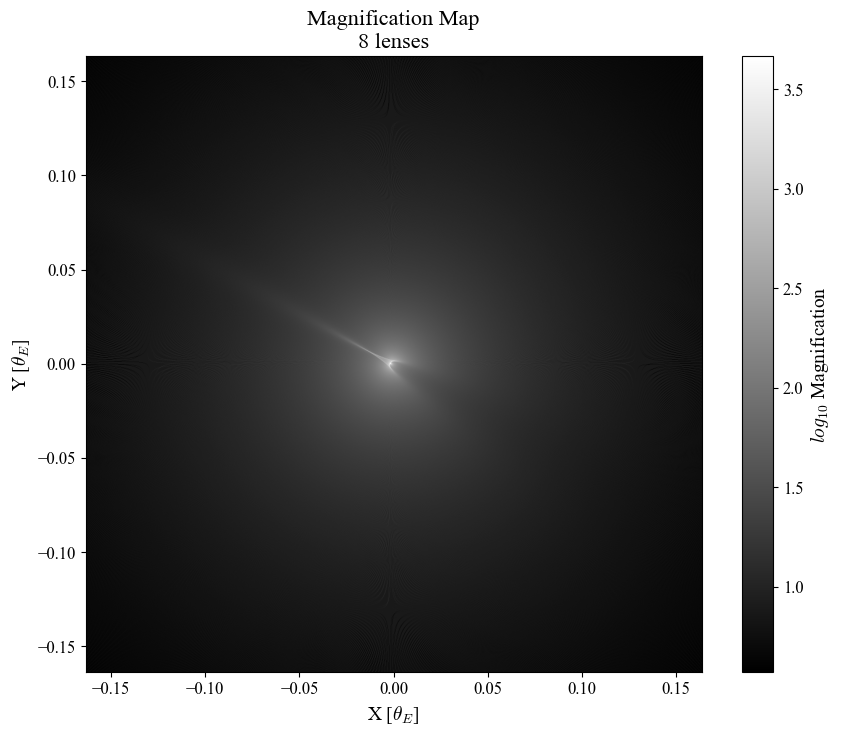

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
1      Venus
3       Mars
0    Mercury
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
Annulus bounds: y+ = 1.1286462721255885, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673680, num_theta = 418420, Total number of rays: 7.003e+11


100%|██████████| 500/500 [00:04<00:00, 110.17it/s]


---------------------
Total time: 4.542 seconds
Plotting magnification map: 0.014 seconds


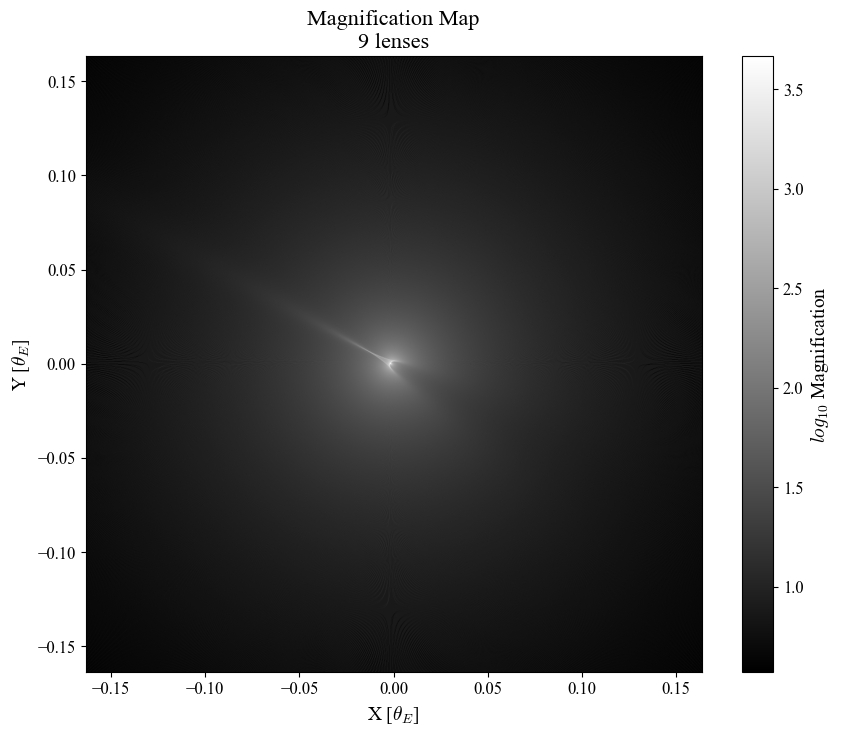

In [47]:
center_of_magnification = np.array([planet_attributes['q'].iloc[0] / ((1 + planet_attributes['q'].iloc[0]) * (planet_attributes['s'].iloc[0] + 1/planet_attributes['s'].iloc[0])), 0])
print(f'Binary offset: {center_of_magnification}')

lens_att[:, :2] -= center_of_magnification

# Iterating over all planets and consecutively creating magnification maps
for i in range(len(planets)):
    current_lens_att = lens_att[0:i+2, :]
    current_planets = planet_attributes['Planet'].iloc[0:i+1]
    print(current_planets)

    pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(current_lens_att, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')
    print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

    (y_plus, y_minus), min_mag = IRSF.IRSFunctions._annulus_bounds_calculator(ang_width, qs, ss)
    print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

    num_r, num_theta = IRSF.IRSFunctions._num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
    print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}, Total number of rays: {(num_r * num_theta):.3e}')

    lens_parameters = {
        'pixels': 1000,
        'ang_width': ang_width,
        'thickness': y_plus - y_minus,
        'y_plus': y_plus,
        'y_minus': y_minus,
        'lens_att': current_lens_att.tolist(),
        'num_theta': 5000,
        'num_r': 20000
    }
    
    sim_current_lens = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
    magnifications_current_lens = sim_current_lens.series_calculate(cm_offset='auto')
    sim_current_lens.plot()

    plt.show()

In [56]:
f'{current_planets.str.join("_")}.pkl'

'4    J_u_p_i_t_e_r\n5      S_a_t_u_r_n\n6      U_r_a_n_u_s\n7    N_e_p_t_u_n_e\n2        E_a_r_t_h\n1        V_e_n_u_s\n3          M_a_r_s\n0    M_e_r_c_u_r_y\nName: Planet, dtype: object.pkl'

In [67]:
file_name = current_planets.iloc[0]
for i, planet in enumerate(current_planets.values):
    if i != 0:
        file_name += f'_{planet}'

file_name += '.pkl'

file_name

'Jupiter_Saturn_Uranus_Neptune_Earth_Venus_Mars_Mercury.pkl'